In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import roc_auc_score

In [3]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv'

In [4]:
df = pd.read_csv(data)
df.head()

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NaN,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NaN,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1


### Data preparation
- Check if the missing values are presented in the features.
- If there are missing values:
- For caterogiral features, replace them with 'NA'
- For numerical features, replace with with 0.0
- Split the data into 3 parts: train/validation/test with 60%/20%/20% distribution. Use train_test_split function for that with random_state=1 

In [5]:
df.isna().sum()

lead_source                 128
industry                    134
number_of_courses_viewed      0
annual_income               181
employment_status           100
location                     63
interaction_count             0
lead_score                    0
converted                     0
dtype: int64

In [6]:
df.dtypes

lead_source                     str
industry                        str
number_of_courses_viewed      int64
annual_income               float64
employment_status               str
location                        str
interaction_count             int64
lead_score                  float64
converted                     int64
dtype: object

In [7]:
for col in df.columns:
    print(f"unique values in column '{col}':")
    print(df[col].unique())
    print("-" * 40)

unique values in column 'lead_source':
<StringArray>
['paid_ads', 'social_media', 'events', 'referral', 'organic_search', nan]
Length: 6, dtype: str
----------------------------------------
unique values in column 'industry':
<StringArray>
[            nan,        'retail',    'healthcare',     'education',
 'manufacturing',    'technology',         'other',       'finance']
Length: 8, dtype: str
----------------------------------------
unique values in column 'number_of_courses_viewed':
[1 5 2 3 0 4 6 8 7 9]
----------------------------------------
unique values in column 'annual_income':
[79450. 46992. 78796. ... 45688. 71016. 92855.]
----------------------------------------
unique values in column 'employment_status':
<StringArray>
['unemployed', 'employed', nan, 'self_employed', 'student']
Length: 5, dtype: str
----------------------------------------
unique values in column 'location':
<StringArray>
['south_america',     'australia',        'europe',        'africa',
   'middle_ea

In [8]:
cat = [
    'lead_source',
    'industry',
    'employment_status',
    'location'
]

num = [
    'number_of_courses_viewed',
    'annual_income',
    'interaction_count',
    'lead_score'
]

In [9]:
# For caterogiral features, replace them with 'NA'
# For numerical features, replace with with 0.0

df[cat] = df[cat].fillna('NA')
df[num] = df[num].fillna(0)

### Splitting Data 

In [10]:
train_test_split?

Signature:
train_test_split(
    *arrays,
    test_size=None,
    train_size=None,
    random_state=None,
    shuffle=True,
    stratify=None,
)
Docstring:
Split arrays or matrices into random train and test subsets.

Quick utility that wraps input validation,
``next(ShuffleSplit().split(X, y))``, and application to input data
into a single call for splitting (and optionally subsampling) data into a
one-liner.

Read more in the :ref:`User Guide <cross_validation>`.

Parameters
----------
*arrays : sequence of indexables with same length / shape[0]
    Allowed inputs are lists, numpy arrays, scipy-sparse
    matrices or pandas dataframes.

test_size : float or int, default=None
    If float, should be between 0.0 and 1.0 and represent the proportion
    of the dataset to include in the test split. If int, represents the
    absolute number of test samples. If None, the value is set to the
    complement of the train size. If ``train_size`` is also None, it will
    be set to 0.25.

trai

In [11]:
# Split the data into 3 parts: train/validation/test with 60%/20%/20% distribution. Use train_test_split function for that with random_state=1

df_full_train, df_test = train_test_split(df, test_size = 0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size = 0.25, random_state=1)

In [12]:
len(df), len(df_full_train), len(df_train), len(df_test), len(df_val)

(1462, 1169, 876, 293, 293)

In [13]:
df_full_train = df_full_train.reset_index(drop=True)
df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)

In [14]:
df_train.head().T

,0,1,2,3,4
lead_source,events,referral,organic_search,paid_ads,paid_ads
industry,manufacturing,NA,healthcare,other,education
number_of_courses_viewed,2,1,2,2,0
annual_income,95543.0,54924.0,77352.0,34600.0,43615.0
employment_status,unemployed,student,unemployed,employed,unemployed
location,europe,south_america,europe,south_america,south_america
interaction_count,3,6,2,2,2
lead_score,0.78,0.39,0.22,0.31,0.01
converted,0,1,0,0,0


In [15]:
# set prediction variable (y), in array
y_train = df_train.converted.values
y_val = df_val.converted.values
y_test = df_val.converted.values

In [16]:
# delete the prediction variable
del df_train['converted']
del df_val['converted']
del df_test['converted']

### Training and Modelling 

In [17]:
dv = DictVectorizer(sparse=False)

In [18]:
train_dict = df_train[cat + num].to_dict(orient = 'records')
X_train = dv.fit_transform(train_dict)

In [19]:
model = LogisticRegression()
model.fit(X_train, y_train)

d:\AI & Machine Learning Project\ml-zoomcamp\ml-zoomcamp\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [20]:
val_dict = df_val[cat + num].to_dict(orient = 'records')
X_val = dv.transform(val_dict)

In [21]:
# y_pred = model.predict_[(X_val)
y_pred = model.predict_proba(X_val)[:, 1]
y_pred

array([0.07439965, 0.53298876, 0.69088124, 0.7442877 , 0.78442455,
       0.72484966, 0.9861682 , 0.35035879, 0.32042725, 0.99859052,
       0.93685251, 0.72275375, 0.99596076, 0.09894724, 0.95346535,
       0.98274793, 0.66852585, 0.10253095, 0.85655087, 0.92702387,
       0.93799402, 0.15087617, 0.98198661, 0.53885542, 0.99836545,
       0.32060472, 0.03151001, 0.97404429, 0.82808667, 0.67115837,
       0.84087834, 0.37907983, 0.35794449, 0.99890769, 0.38642073,
       0.86647208, 0.94711947, 0.84051514, 0.16449537, 0.14797723,
       0.98643052, 0.06063908, 0.39483516, 0.70615583, 0.80503919,
       0.2503161 , 0.50145456, 0.61852667, 0.62300423, 0.98747639,
       0.88115344, 0.16285311, 0.99528484, 0.96320652, 0.93721685,
       0.86457656, 0.80347092, 0.61458332, 0.35726023, 0.77393216,
       0.0093055 , 0.52505639, 0.06674314, 0.57932054, 0.52833674,
       0.0783968 , 0.83064829, 0.0277674 , 0.42301519, 0.68246732,
       0.96853064, 0.51884862, 0.25144313, 0.98802169, 0.62198

In [22]:
y_pred_proba = model.predict_proba(X_val)[:, 1]
y_pred_proba

array([0.07439965, 0.53298876, 0.69088124, 0.7442877 , 0.78442455,
       0.72484966, 0.9861682 , 0.35035879, 0.32042725, 0.99859052,
       0.93685251, 0.72275375, 0.99596076, 0.09894724, 0.95346535,
       0.98274793, 0.66852585, 0.10253095, 0.85655087, 0.92702387,
       0.93799402, 0.15087617, 0.98198661, 0.53885542, 0.99836545,
       0.32060472, 0.03151001, 0.97404429, 0.82808667, 0.67115837,
       0.84087834, 0.37907983, 0.35794449, 0.99890769, 0.38642073,
       0.86647208, 0.94711947, 0.84051514, 0.16449537, 0.14797723,
       0.98643052, 0.06063908, 0.39483516, 0.70615583, 0.80503919,
       0.2503161 , 0.50145456, 0.61852667, 0.62300423, 0.98747639,
       0.88115344, 0.16285311, 0.99528484, 0.96320652, 0.93721685,
       0.86457656, 0.80347092, 0.61458332, 0.35726023, 0.77393216,
       0.0093055 , 0.52505639, 0.06674314, 0.57932054, 0.52833674,
       0.0783968 , 0.83064829, 0.0277674 , 0.42301519, 0.68246732,
       0.96853064, 0.51884862, 0.25144313, 0.98802169, 0.62198

### Validation using Several Metrics 

#### Accuracy 

In [23]:
converted_decision = (y_pred_proba >= 0.5)
(y_val == converted_decision).mean()

np.float64(0.8020477815699659)

In [24]:
accuracy_score(y_true=y_val, y_pred=(y_pred_proba >= 0.5))

0.8020477815699659

In [25]:
thresholds = np.linspace(0, 1, 21)

scores = []

for t in thresholds:
    score = accuracy_score(y_val, y_pred_proba >= t)
    print('%.2f %.3f' % (t, score))
    scores.append(score)

0.00 0.584
0.05 0.614
0.10 0.652
0.15 0.672
0.20 0.710
0.25 0.710
0.30 0.744
0.35 0.761
0.40 0.788
0.45 0.795
0.50 0.802
0.55 0.812
0.60 0.819
0.65 0.819
0.70 0.812
0.75 0.788
0.80 0.758
0.85 0.710
0.90 0.683
0.95 0.611
1.00 0.416


<function matplotlib.pyplot.show(close=None, block=None)>

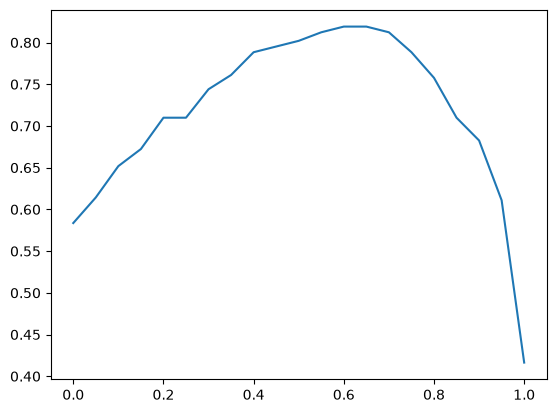

In [26]:
plt.plot(thresholds, scores)
plt.show

#### Confusion table

In [27]:
actual_positive = (y_val == 1).sum()
actual_negative = (y_val == 0).sum()

t = 0.5

predict_positive = (y_pred >= t).sum()
predict_negative = (y_pred < t).sum()

actual_positive, actual_negative, predict_positive, predict_negative

(np.int64(171), np.int64(122), np.int64(191), np.int64(102))

In [28]:
tp = (predict_positive & actual_positive).sum()
tn = (predict_negative & actual_negative).sum()
fp = (predict_positive & actual_negative).sum()
fn = (predict_negative & actual_positive).sum()

tp, tn, fp, fn

(np.int64(171), np.int64(98), np.int64(58), np.int64(34))

In [29]:
confusion_matrix = np.array([
    [tn, fp],
    [fn, tp]
])
confusion_matrix

array([[ 98,  58],
       [ 34, 171]])

In [30]:
(confusion_matrix / confusion_matrix.sum()).round(2)

array([[0.27, 0.16],
       [0.09, 0.47]])

#### Precision and recall 

In [31]:
p = (tp / (tp+fp)).round(2)
r = (tp / (tp+fn)).round(2)

p,r

(np.float64(0.75), np.float64(0.83))

#### ROC 

In [32]:
tpr = (tp / (tp+fn)).round(2)
fpr = (fp / (fp+tn)).round(2)

In [33]:
thresholds = np.linspace(0, 1, 101)

scores = []

for t in thresholds:
    actual_positive = (y_val == 1)
    actual_negative = (y_val == 0)
       
    predict_positive = (y_pred >= t)
    predict_negative = (y_pred < t)

    tp = (predict_positive & actual_positive).sum()
    tn = (predict_negative & actual_negative).sum()
    
    fp = (predict_positive & actual_negative).sum()
    fn = (predict_negative & actual_positive).sum()
    
    scores.append((t, tp, fp, fn, tn))

In [34]:
pd.DataFrame?

Init signature:
pd.DataFrame(
    data=None,
    index: 'Axes | None' = None,
    columns: 'Axes | None' = None,
    dtype: 'Dtype | None' = None,
    copy: 'bool | None' = None,
) -> 'None'
Docstring:     
Two-dimensional, size-mutable, potentially heterogeneous tabular data.

Data structure also contains labeled axes (rows and columns).
Arithmetic operations align on both row and column labels. Can be
thought of as a dict-like container for Series objects. The primary
pandas data structure.

Parameters
----------
data : ndarray (structured or homogeneous), Iterable, dict, or DataFrame
    Dict can contain Series, arrays, constants, dataclass or list-like objects. If
    data is a dict, column order follows insertion-order. If a dict contains Series
    which have an index defined, it is aligned by its index. This alignment also
    occurs if data is a Series or a DataFrame itself. Alignment is done on
    Series/DataFrame inputs.

    If data is a list of dicts, column order follows 

In [35]:
columns = 'threshold', 'tp', 'fp', 'fn', 'tn'
df_scores = pd.DataFrame(scores, columns=columns)
df_scores

,threshold,tp,fp,fn,tn
0,0.00,171,122,0,0
1,0.01,171,120,0,2
2,0.02,171,118,0,4
3,0.03,171,116,0,6
4,0.04,171,114,0,8
...,...,...,...,...,...
96,0.96,51,1,120,121
97,0.97,44,1,127,121
98,0.98,33,0,138,122
99,0.99,20,0,151,122


In [81]:
df_scores['tpr'] = (df_scores.tp / (df_scores.tp + df_scores.fn)).round(2)
df_scores['fpr'] = (df_scores.fp / (df_scores.fp + df_scores.tn)).round(2)

In [82]:
df_scores[::10]

,threshold,tp,fp,fn,tn,tpr,fpr
0,0.0,171,122,0,0,1.00,1.00
10,0.1,170,101,1,21,0.99,0.83
20,0.2,166,80,5,42,0.97,0.66
30,0.3,164,68,7,54,0.96,0.56
40,0.4,157,48,14,74,0.92,0.39
50,0.5,152,39,19,83,0.89,0.32
60,0.6,144,26,27,96,0.84,0.21
70,0.7,130,14,41,108,0.76,0.11
80,0.8,110,10,61,112,0.64,0.08
90,0.9,82,4,89,118,0.48,0.03


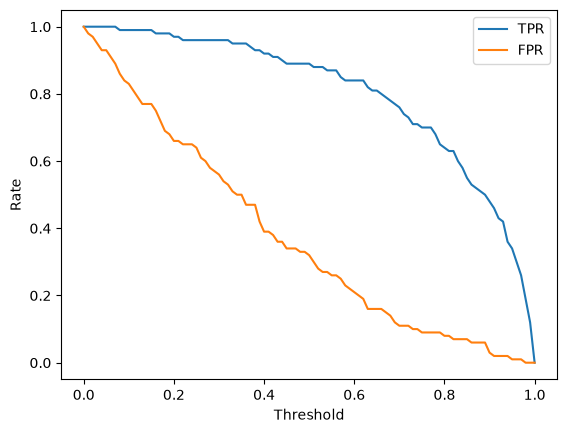

In [83]:
plt.plot(df_scores.threshold, df_scores['tpr'], label='TPR')
plt.plot(df_scores.threshold, df_scores['fpr'], label='FPR')

plt.xlabel("Threshold") 
plt.ylabel("Rate")  
plt.legend()
plt.show()

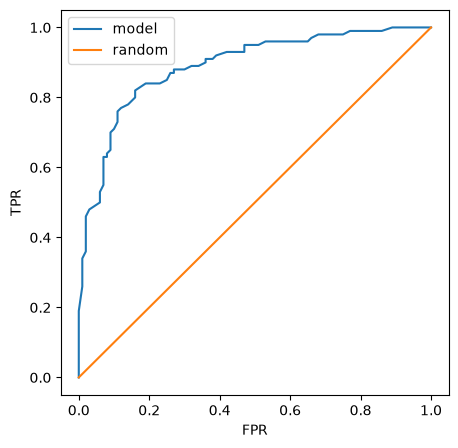

In [84]:
plt.figure(figsize=(5, 5))

plt.plot(df_scores.fpr, df_scores.tpr, label='model')
plt.plot([0, 1], [0, 1], label='random')
# plt.plot(df_rand.fpr, df_rand.tpr, label='random')
# plt.plot(df_ideal.fpr, df_ideal.tpr, label='ideal')

plt.xlabel('FPR')
plt.ylabel('TPR')

plt.legend()

#### ROC using sklearn 

In [85]:
fpr, tpr, thresholds = roc_curve(y_val, y_pred)

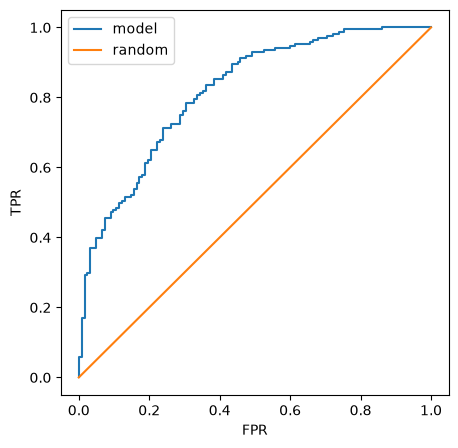

In [86]:
plt.figure(figsize=(5, 5))

plt.plot(fpr, tpr, label='model')
plt.plot([0, 1], [0, 1], label='random')
# plt.plot(df_rand.fpr, df_rand.tpr, label='random')
# plt.plot(df_ideal.fpr, df_ideal.tpr, label='ideal')

plt.xlabel('FPR')
plt.ylabel('TPR')

plt.legend()

#### ROC AUC

In [87]:
auc(fpr, tpr)

0.8171316268814112

In [88]:
roc_auc_score(y_val, y_pred)

0.8171316268814112

### Q1 

ROC AUC could also be used to evaluate feature importance of numerical variables.

Let's do that

- For each numerical variable, use it as score and compute AUC with the above_average variable
- Use the training dataset for that
- If your AUC is < 0.5, invert this variable by putting "-" in front

(e.g. -df_train['engine_hp'])

- AUC can go below 0.5 if the variable is negatively correlated with the target varialble. You can change the direction of the correlation by negating this variable - then negative correlation becomes positive.

In [44]:
from sklearn.metrics import roc_auc_score, roc_curve

In [91]:
df_train[num]

,number_of_courses_viewed,annual_income,interaction_count,lead_score
0,2,95543.0,3,0.78
1,1,54924.0,6,0.39
2,2,77352.0,2,0.22
3,2,34600.0,2,0.31
4,0,43615.0,2,0.01
...,...,...,...,...
871,5,67314.0,2,0.87
872,6,63996.0,4,0.92
873,1,73702.0,2,0.55
874,1,93341.0,4,0.99


In [92]:
for c in num:
    auc_df = roc_auc_score(y_train, df_train[c])
    if auc_df < 0.5:
        auc_df = roc_auc_score(y_train, -df_train[c])
    print('%16s, %.3f' % (c, auc_df))

number_of_courses_viewed, 0.764
   annual_income, 0.552
interaction_count, 0.738
      lead_score, 0.614


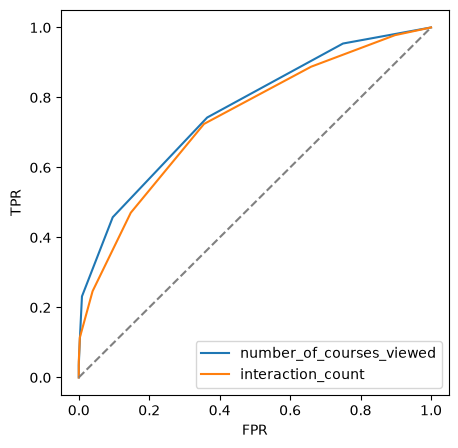

In [47]:
plt.figure(figsize=(5, 5))

fpr, tpr, _ = roc_curve(y_train, df_train.number_of_courses_viewed)
plt.plot(fpr, tpr, label='number_of_courses_viewed')

fpr, tpr, _ = roc_curve(y_train, df_train.interaction_count)
plt.plot(fpr, tpr, label='interaction_count')

plt.plot([0, 1], [0, 1], color='grey', linestyle='--')

plt.xlabel('FPR')
plt.ylabel('TPR')

plt.legend()
plt.show()

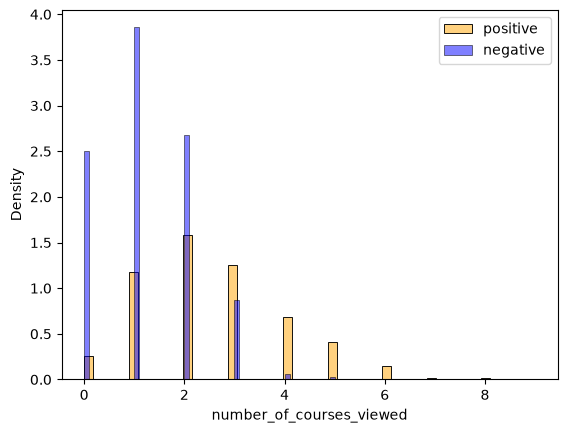

In [48]:
sns.histplot(df_train.number_of_courses_viewed[y_train == 1],
             stat='density', bins=50,
             color='orange', alpha=0.5,
             label='positive')
sns.histplot(df_train.number_of_courses_viewed[y_train == 0],
             stat='density', bins=50,
             color='blue', alpha=0.5,
             label='negative')

plt.legend()
plt.show()

### Question 2: Training the model
Apply one-hot-encoding using DictVectorizer and train the logistic regression with these parameters:

LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)

What's the AUC of this model on the validation dataset? (round to 3 digits)

- 0.32
- 0.52
- 0.72
- 0.92

In [115]:
dv = DictVectorizer(sparse = False)
train_dict = df_train[cat + num].to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

In [116]:
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
model.fit(X_train, y_train)

,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalt

In [117]:
val_dict = df_val[cat + num].to_dict(orient='records')
X_val = dv.transform(val_dict)

In [118]:
y_pred = model.predict_proba(X_val)[:, 1]

fpr, tpr, thresholds = roc_curve(y_val, y_pred)

In [119]:
roc_auc_score(y_val, y_pred)

0.8171316268814112

In [120]:
auc(fpr, tpr)

0.8171316268814112

### Question 3: Precision and Recall
Now let's compute precision and recall for our model.

- Evaluate the model on all thresholds from 0.0 to 1.0 with step 0.01
- For each threshold, compute precision and recall
- Plot them 

In [127]:
def confusion_matrix_dataframe(y_val, y_pred):

    scores = []
    
    thresholds = np.linspace(0, 1, 101)  
    
    for t in thresholds:
        actual_positive = (y_val == 1)
        actual_negative = (y_val == 0)
           
        predict_positive = (y_pred >= t)
        predict_negative = (y_pred < t)
    
        tp = (predict_positive & actual_positive).sum()
        tn = (predict_negative & actual_negative).sum()
        
        fp = (predict_positive & actual_negative).sum()
        fn = (predict_negative & actual_positive).sum()
        
        scores.append((t, tp, fp, fn, tn))

    columns = ['threshold', 'tp', 'fp', 'fn', 'tn']
    df_scores = pd.DataFrame(scores, columns=columns)
    
    return df_scores

In [128]:
df_scores = confusion_matrix_dataframe(y_val, y_pred)

In [132]:
df_scores[::10]

,threshold,tp,fp,fn,tn
0,0.0,171,122,0,0
10,0.1,171,122,0,0
20,0.2,171,122,0,0
30,0.3,171,119,0,3
40,0.4,171,105,0,17
50,0.5,164,81,7,41
60,0.6,150,53,21,69
70,0.7,106,25,65,97
80,0.8,64,6,107,116
90,0.9,24,1,147,121


In [133]:
df_scores['p'] = df_scores.tp / (df_scores.tp + df_scores.fp)
df_scores['r'] = df_scores.tp / (df_scores.tp + df_scores.fn)

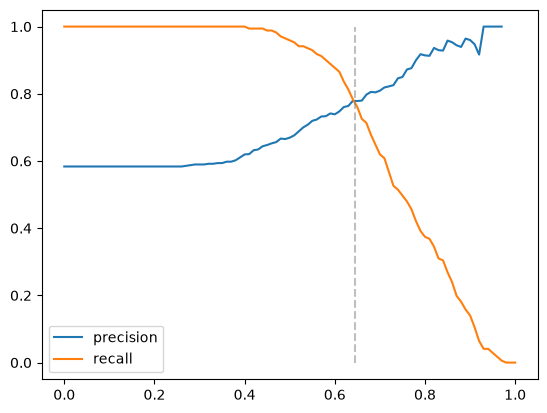

In [137]:
plt.plot(df_scores.threshold, df_scores.p, label='precision')
plt.plot(df_scores.threshold, df_scores.r, label='recall')

plt.vlines(0.645, 0, 1, color='grey', linestyle='--', alpha=0.5)

plt.legend()
plt.show()